# Tasks:

**1.	Data Cleaning and Preparation:**

●	Load the dataset into a DataFrame or equivalent data structure.

●	Handle missing values appropriately (e.g., imputation, deletion).

●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).

●	Detect and treat outliers if necessary.


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Cardiotocographic.csv")
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [43]:
df.shape

(2126, 14)

In [44]:
df.isnull().sum()

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


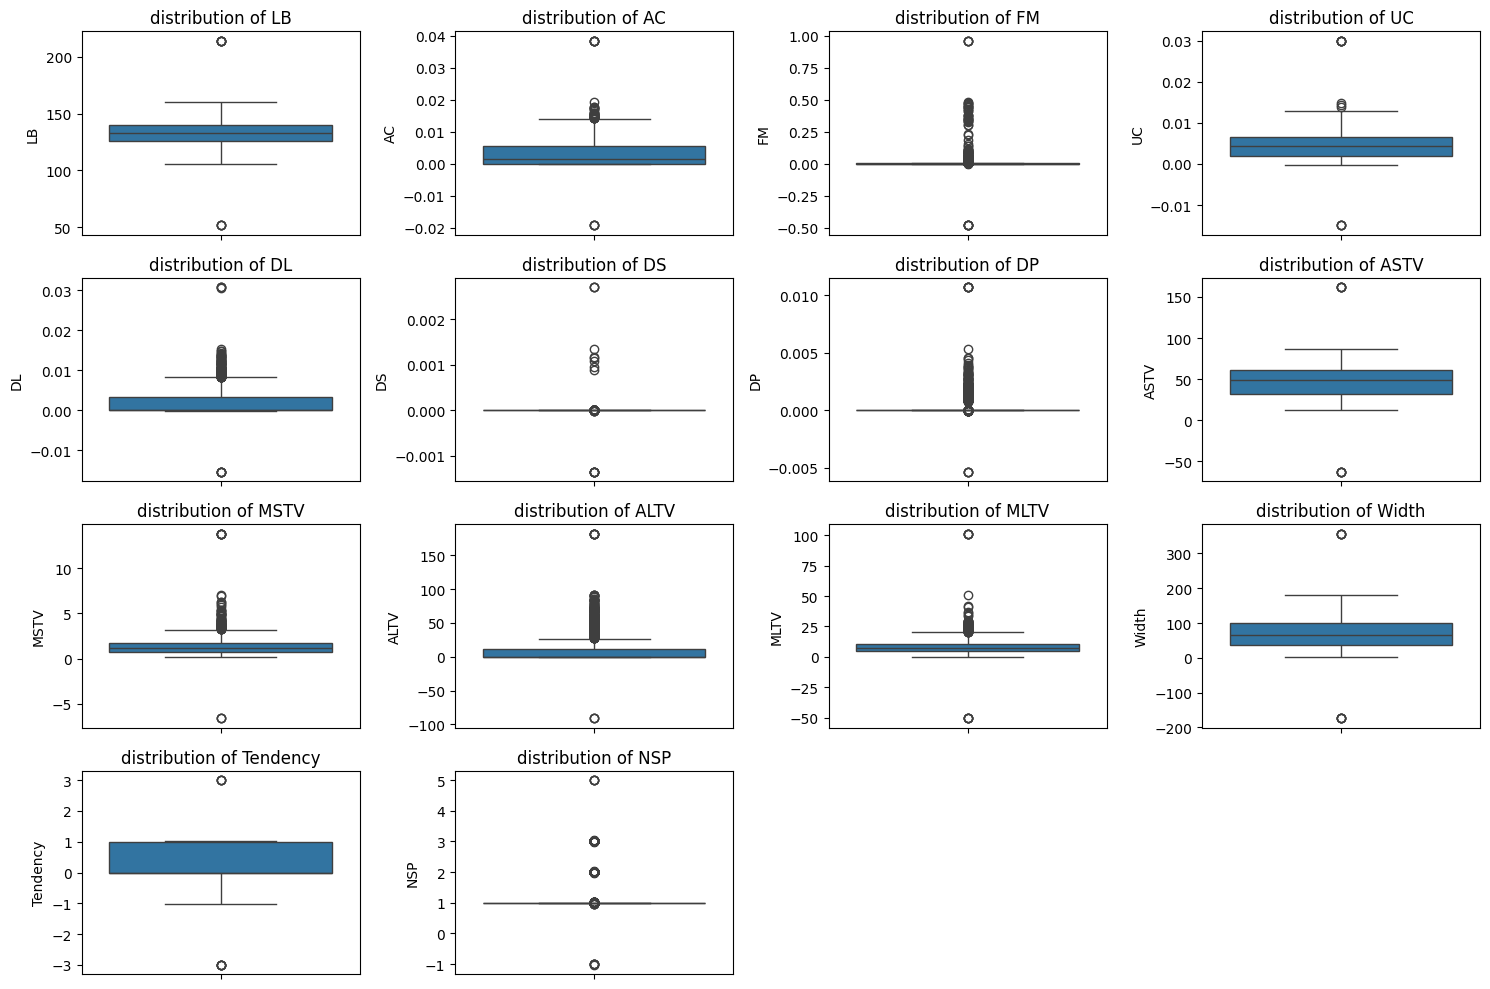

In [46]:
plt.figure(figsize=(15,10))
for col in df.columns:
    plt.subplot(4,4,df.columns.get_loc(col)+1)
    sns.boxplot(df[col])
    plt.title(f"distribution of {col}")
plt.tight_layout()
plt.show()

In [47]:
df = df.fillna(df.median())

print("Missing values after imputing all columns with their medians:")
display(df.isnull().sum())

Missing values after imputing all columns with their medians:


,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [48]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df < lower_bound) | (df > upper_bound)

total_outliers = outliers.sum().sum()
if total_outliers > 0:
    print(f"Yes, there are {total_outliers} outlier values present across the dataset.")
    print("Here is a summary of outliers per column:")
    display(outliers.sum())
else:
    print("No outliers were found in the dataset.")

Yes, there are 2010 outlier values present across the dataset.
Here is a summary of outliers per column:


,0
LB,10
AC,43
FM,347
UC,13
DL,125
DS,120
DP,284
ASTV,10
MSTV,80
ALTV,318


**2.	Statistical Summary:**

●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).

●	Highlight any interesting findings from this summary.


In [49]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [55]:
for column in df.columns:
    if column in lower_bound.index and column in upper_bound.index:
        df[column] = df[column].clip(lower=lower_bound[column], upper=upper_bound[column])

print("DataFrame after capping outliers:")
df.head()

DataFrame after capping outliers:


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,27.5,2.4,64.0,0.999926,1.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,20.1,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [56]:
print("Descriptive statistics after capping outliers:")
df.describe()

Descriptive statistics after capping outliers:


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0
mean,133.290331,0.003132,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.007471,70.287203,0.316537,1.0
std,9.930268,0.003828,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.047078,39.571995,0.622406,0.0
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


**3.	Data Visualization:**

●	Create histograms or boxplots to visualize the distributions of various numerical variables.

●	Use bar charts or pie charts to display the frequency of categories for categorical variables.

●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.

●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


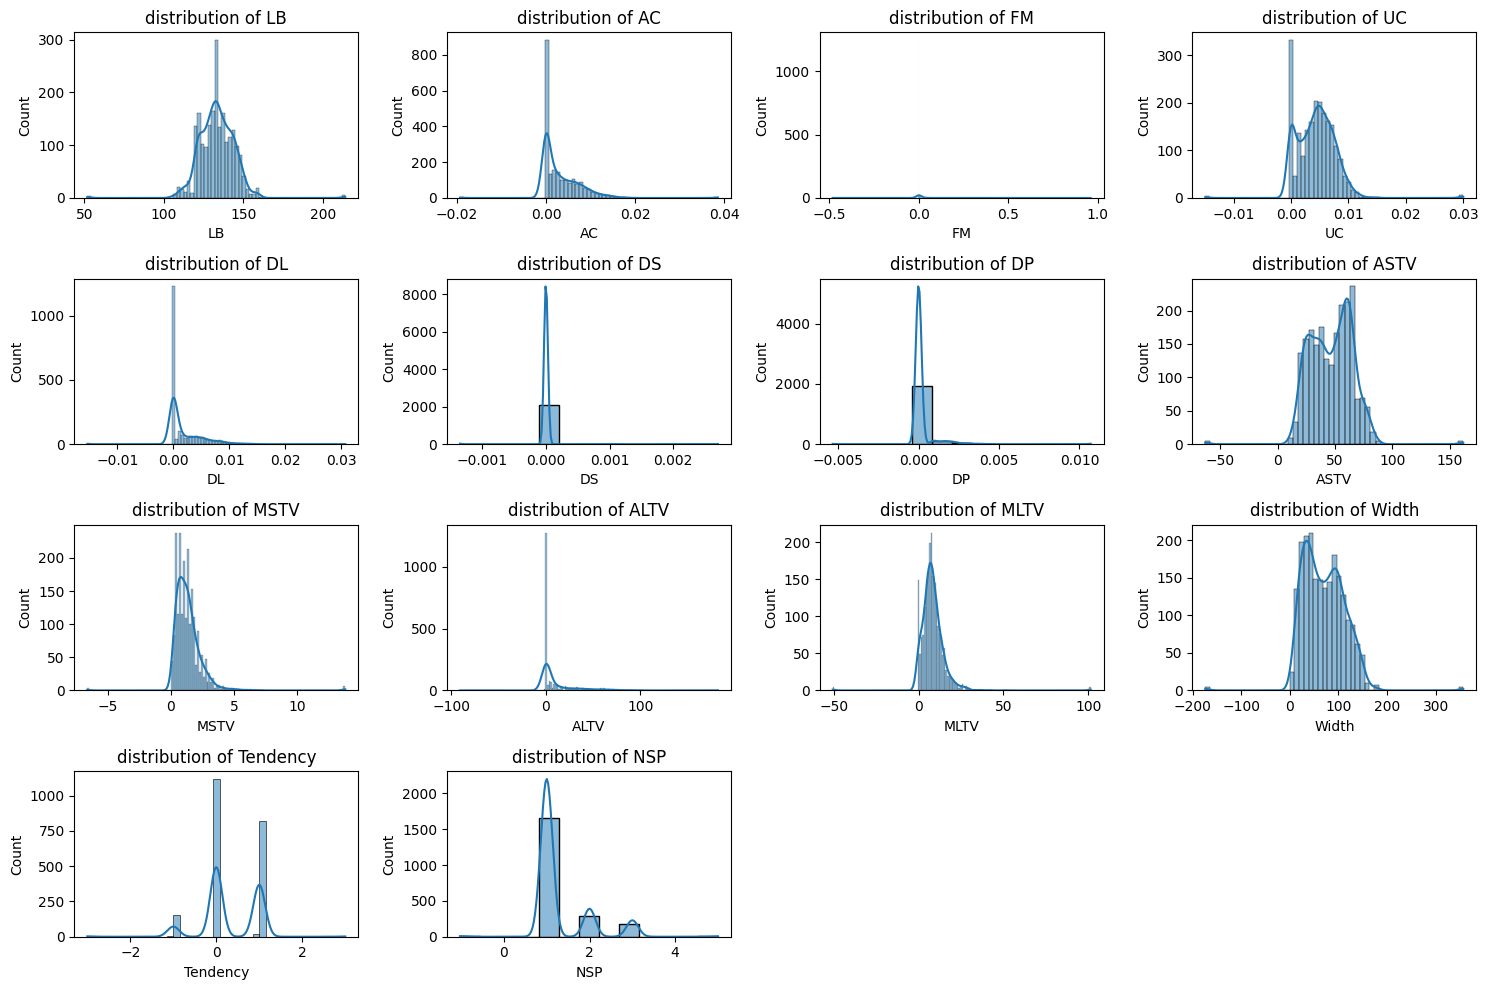

In [50]:
plt.figure(figsize=(15,10))
for col in df.columns:
    plt.subplot(4,4,df.columns.get_loc(col)+1)
    sns.histplot(df[col],kde=True)
    plt.title(f"distribution of {col}")
plt.tight_layout()
plt.show()

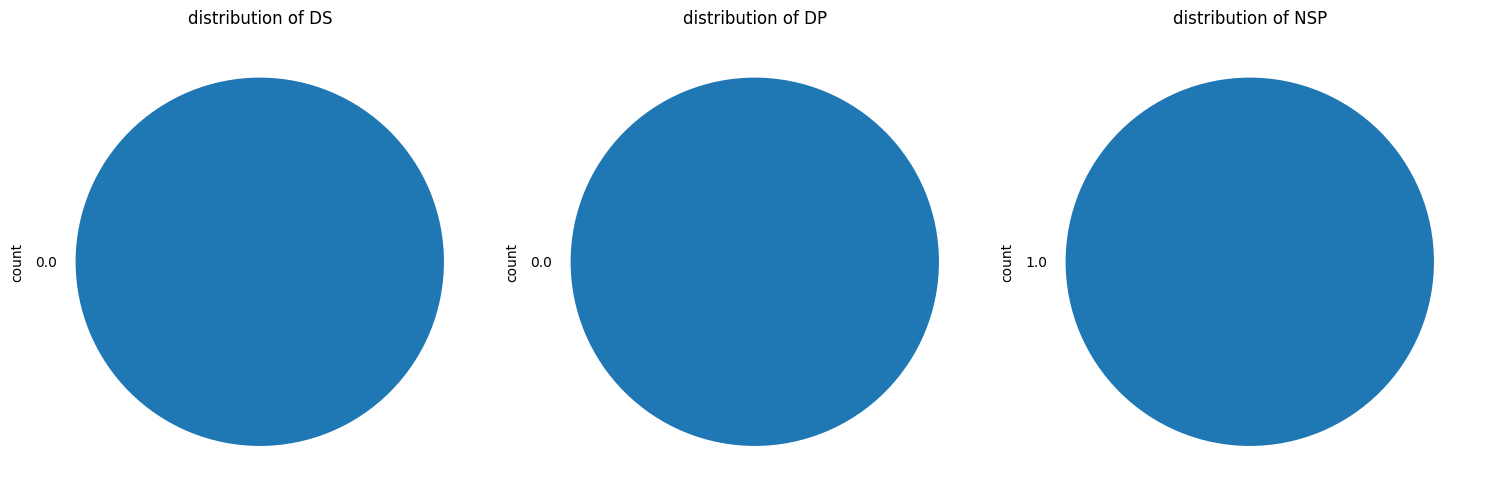

In [61]:
plt.kind='pie'
plt.figure(figsize=(15,10))
for col in cat_var:
    plt.subplot(1,3,cat_var.index(col)+1)
    df[col].value_counts().plot(kind='pie')
    plt.title(f"distribution of {col}")
plt.tight_layout()
plt.show()

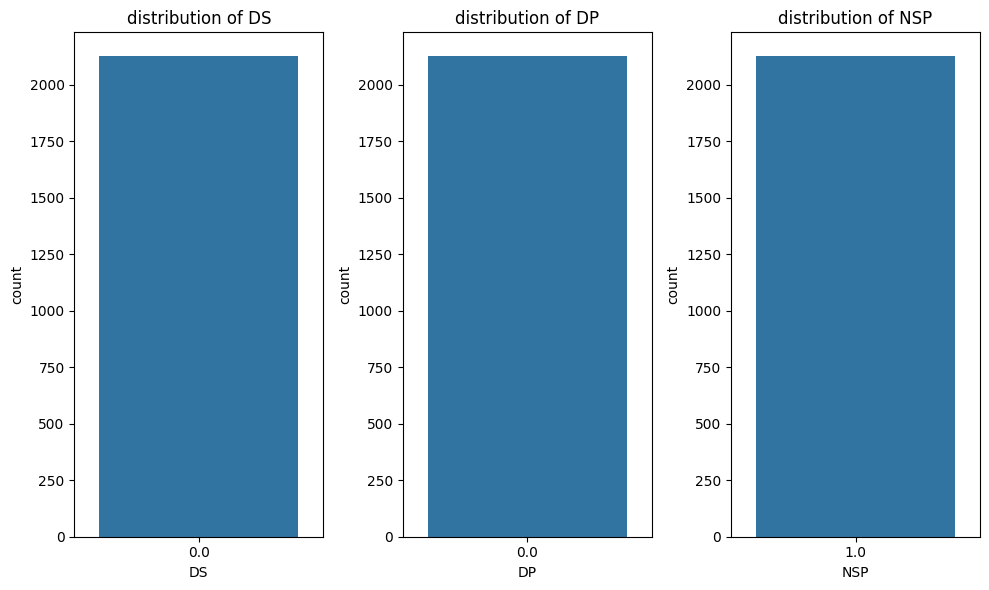

In [57]:
cat_var=['DS','DP','NSP']
plt.figure(figsize=(10,6))
for col in cat_var:
    plt.subplot(1,3,cat_var.index(col)+1)
    sns.countplot(x=df[col])
    plt.title(f"distribution of {col}")
plt.tight_layout()
plt.show()

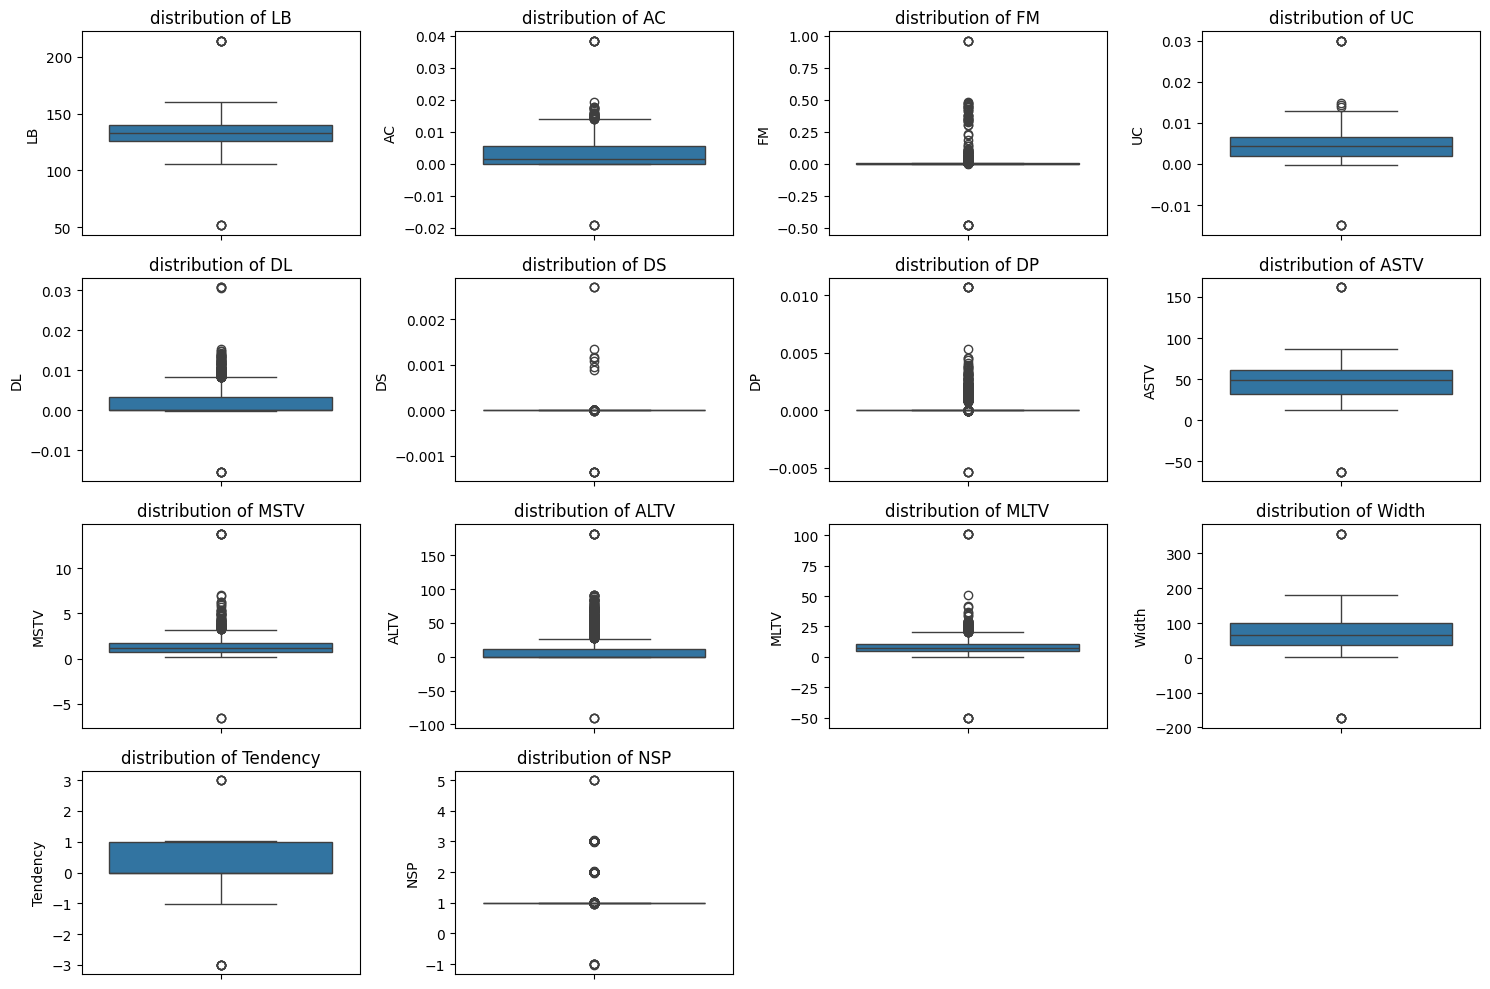

In [52]:
plt.figure(figsize=(15,10))
for col in df.columns:
    plt.subplot(4,4,df.columns.get_loc(col)+1)
    sns.boxplot(y=df[col])
    plt.title(f"distribution of {col}")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

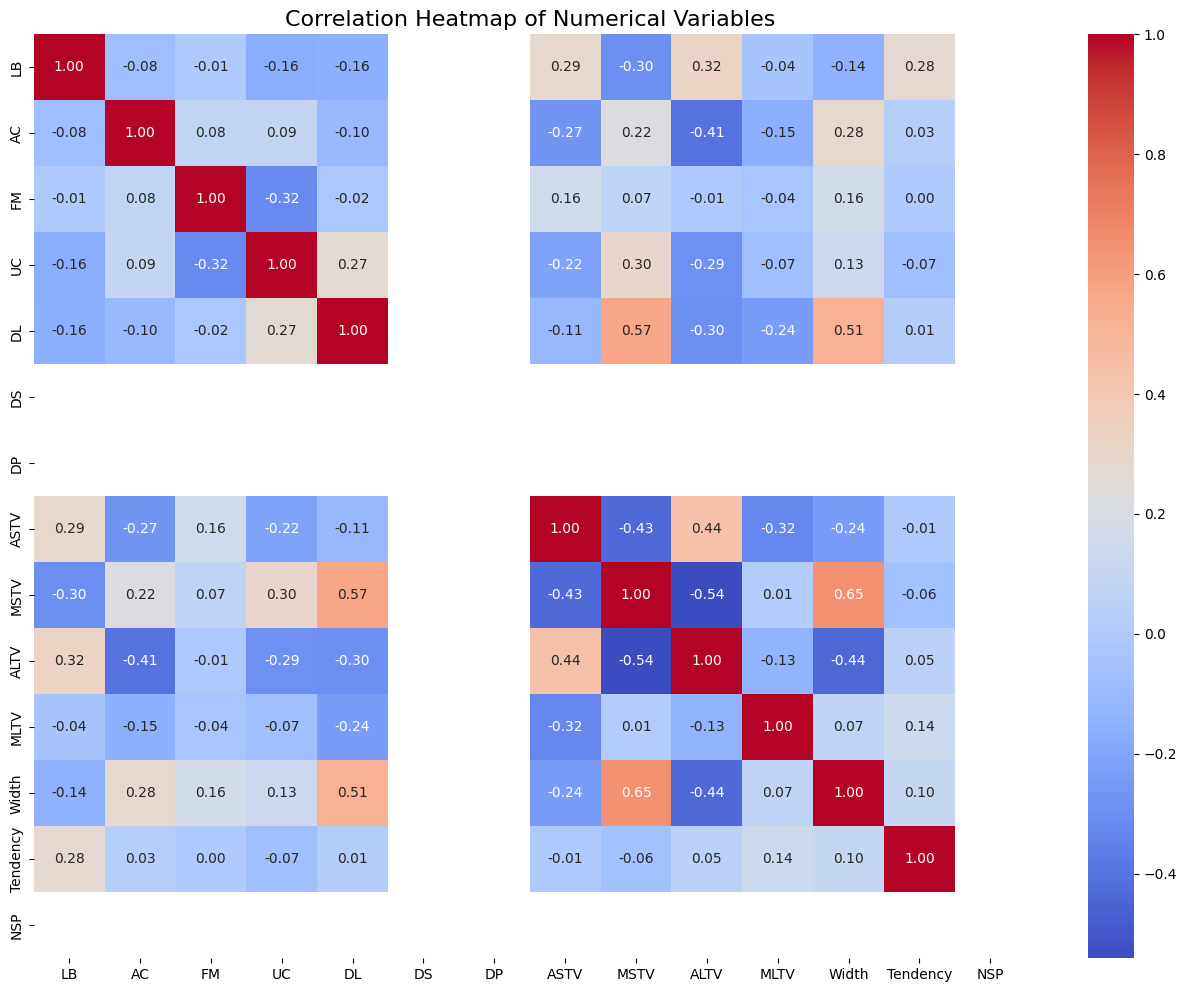

In [58]:
correlation_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

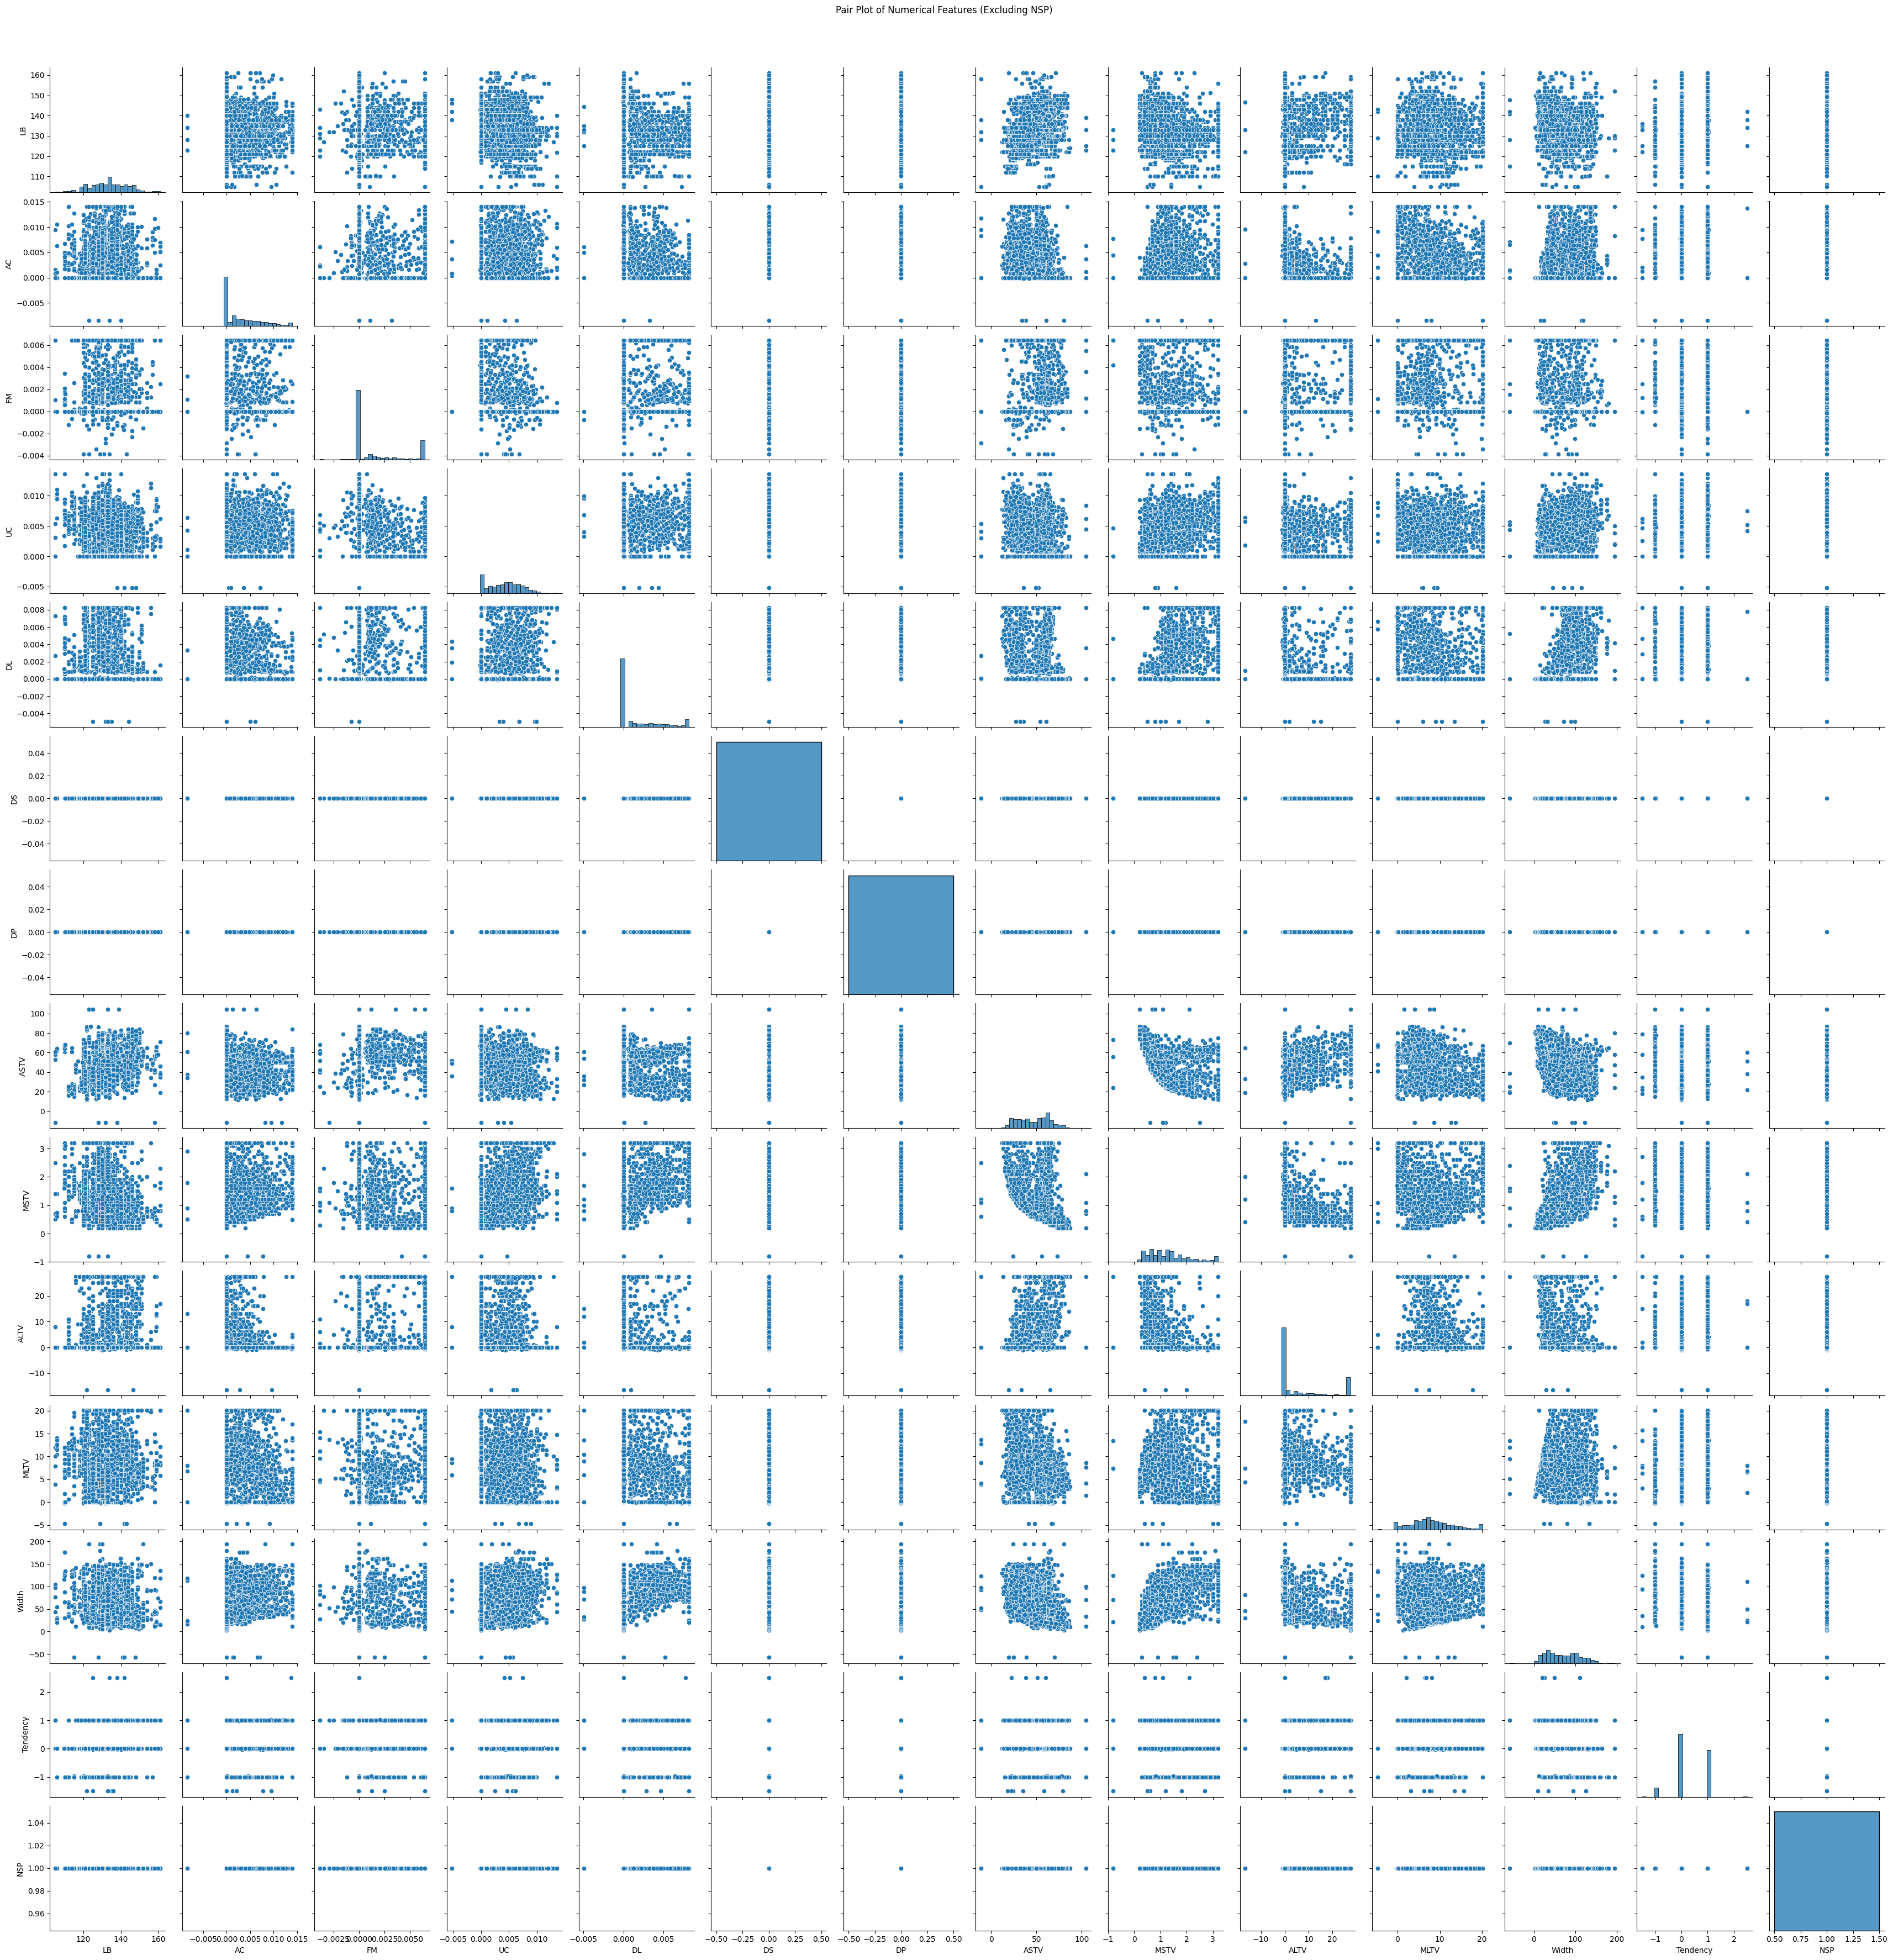

In [65]:
sns.pairplot(df)
plt.suptitle('Pair Plot of Numerical Features (Excluding NSP)', y=1.02) # Add a title to the entire figure
plt.show()

**4.	Pattern Recognition and Insights:**

●	Identify any correlations between variables and discuss their potential implications.

●	Look for trends or patterns over time if temporal data is available.



**Key Correlations Identified:**

LB (Basal FHR) showed moderate negative correlations with AC (Accelerations) and UC (Uterine Contractions), and a positive correlation with ALTV (Long Term Variability).

AC and UC were positively correlated with each other.

NSP (Fetal State Class) displayed weak linear correlations with most other variables, hinting at more complex, non-linear relationships.

**Skewed Distributions:**

 Many numerical variables, including AC, FM, UC, DL, DS, DP, ALTV, Tendency, and NSP, exhibit highly skewed distributions, often concentrated at zero or specific values.

**5.	Conclusion:**

●	Summarize the key insights and patterns discovered through your exploratory analysis.
●	Discuss how these findings could impact decision-making or further analyses.

**Conclusion**, the data cleaning process significantly improved the dataset's quality. The statistical and visual analyses revealed important distributional characteristics and inter-variable relationships, setting a strong foundation for subsequent modeling efforts and clinical interpretations. Special attention should be paid to the treatment of NSP, DS, and DP as categorical variables and to exploring non-linear relationships in future analyses.